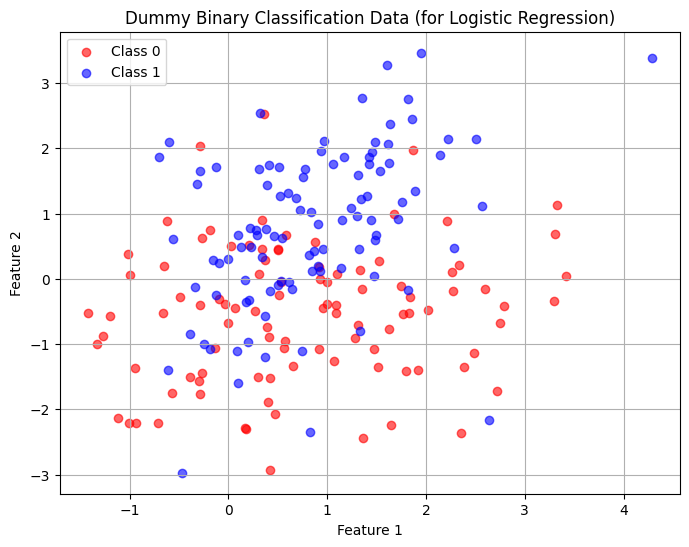

Features shape: (200, 2)
Target shape: (200,)


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
import math

# Set seed
np.random.seed(42)

# Generate a classification dataset
x, y = make_classification(
    n_samples=200,
    n_features=2,          # Only 2 useful features for visualization
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.8,         # Low separation makes it harder
    flip_y=0.1,            # Add noise (10% label flipping)
    random_state=42
)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print("Features shape:", x.shape)
print("Target shape:", y.shape)

In [26]:
def sigmoid_function(z):
    sigmoid = 1/(1 + np.exp(-z))

    return sigmoid

In [27]:
def create_polynomial_features(X, degree):
    """
    Create polynomial features including all combinations of 2 features up to 'degree'.
    """
    from itertools import combinations_with_replacement
    
    n_samples, n_features = X.shape
    features = []  # bias term (column of 1s)
    
    # Loop over degrees
    for d in range(1, degree + 1):
        for items in combinations_with_replacement(range(n_features), d):
            new_feature = np.prod(X[:, items], axis=1)
            features.append(new_feature)
    
    return np.vstack(features).T

In [28]:
x_mean = np.mean(x, axis=0)
x_std = np.std(x, axis=0)

# Apply standardization (Z-score normalization)
# Formula: (x - mean) / std
# Adding small value (1e-8) to avoid division by zero
x_scaled = (x - x_mean) / (x_std + 1e-8)

In [29]:
degree = 4
X_poly = create_polynomial_features(x_scaled, degree)
y_reshape = y.reshape(-1, 1)

In [30]:
m, n_features_poly = X_poly.shape
w = np.random.randn(n_features_poly, 1)
iteration = 20000
m = len(x)
learning_rate = 0.0012
cost_ = []
b = 0 
for _ in range(iteration):
    z = X_poly @ w  + b
    f_wb =  sigmoid_function(z) # Apply sigmoid function to get predictions (probabilities)

    # Compute logistic regression cost (binary cross-entropy)
    cost =  (-1/m) * np.sum((y_reshape*np.log(f_wb + 1e-8) + (1 - y_reshape)*np.log(1 - f_wb + 1e-8) ))
    cost_.append(cost)
    
    dw = np.transpose(X_poly) @ (f_wb - y_reshape)/m
    db = np.sum((f_wb - y_reshape))/m

    w = w - learning_rate * dw
    b = b - learning_rate * db
    if _ % 500 == 0:
        print(f"Epoch {_}: Cost = {cost}")
print("Final cost :", cost)

Epoch 0: Cost = 2.767664787366804
Epoch 500: Cost = 1.512229005396729
Epoch 1000: Cost = 0.8527371254188197
Epoch 1500: Cost = 0.6949350395117162
Epoch 2000: Cost = 0.6365069123323509
Epoch 2500: Cost = 0.6108838137477446
Epoch 3000: Cost = 0.5946691303566423
Epoch 3500: Cost = 0.5835550307001803
Epoch 4000: Cost = 0.5750905768806289
Epoch 4500: Cost = 0.5680719702780919
Epoch 5000: Cost = 0.5618986287344719
Epoch 5500: Cost = 0.5562698606439045
Epoch 6000: Cost = 0.5510345281173097
Epoch 6500: Cost = 0.5461186841896185
Epoch 7000: Cost = 0.5414920160682505
Epoch 7500: Cost = 0.5371517565060077
Epoch 8000: Cost = 0.5331125823141138
Epoch 8500: Cost = 0.529395798916078
Epoch 9000: Cost = 0.5260158630588906
Epoch 9500: Cost = 0.5229689283922778
Epoch 10000: Cost = 0.5202308742544102
Epoch 10500: Cost = 0.5177653603877153
Epoch 11000: Cost = 0.5155341408259168
Epoch 11500: Cost = 0.5135031027811212
Epoch 12000: Cost = 0.5116437204878084
Epoch 12500: Cost = 0.509932395141566
Epoch 13000: C

In [31]:
x1_min, x1_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
x2_min, x2_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5

# Create a mesh grid (2D grid of points) for plotting decision boundary
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                       np.linspace(x2_min, x2_max, 200))

# Flatten grid and combine into (N, 2) shape for model input
grid_points = np.c_[xx1.ravel(), xx2.ravel()]

grid_scaled = (grid_points - x_mean) / (x_std + 1e-8) # Apply same feature scaling as training data
grid_poly = create_polynomial_features(grid_scaled, degree) # Generate polynomial features from scaled grid points

# Compute linear combination (z = Xw + b) for grid
z_grid = grid_poly @ w + b
probs_grid = sigmoid_function(z_grid).reshape(xx1.shape)

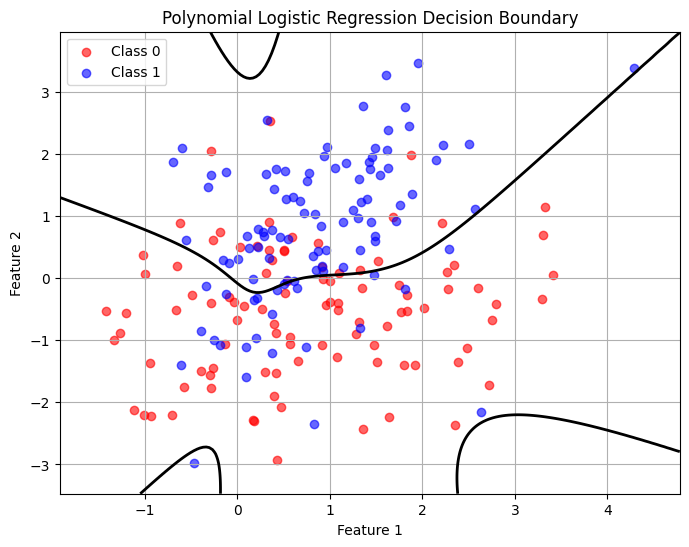

In [32]:
plt.figure(figsize=(8, 6))
plt.contour(xx1, xx2, probs_grid, levels=[0.5], colors='black', linewidths=2)
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Polynomial Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

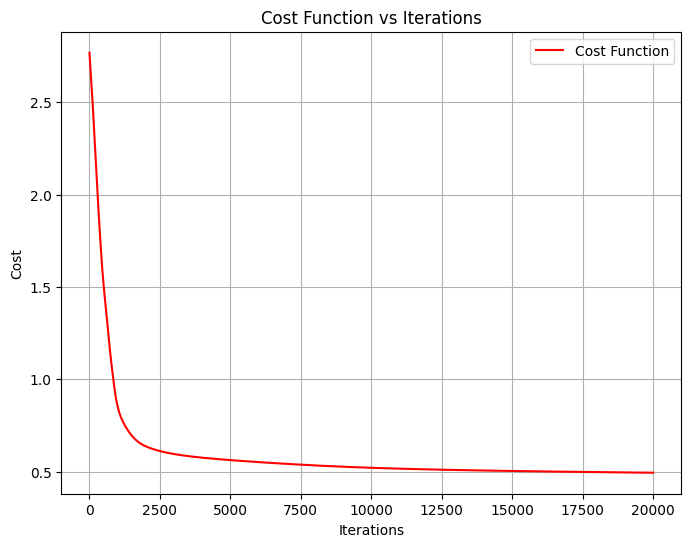

In [33]:
# Create figure for cost visualization
plt.figure(figsize=(8, 6))
plt.plot(cost_, color='red', label="Cost Function")
plt.title("Cost Function vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()
plt.grid(True)
plt.show()